In [1]:
!pip install -q gsplat pycolmap plyfile
import torch
print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 62.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 62.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.9 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.6

In [4]:
DATA_ROOT = "/kaggle/input/datasets/harshit2702/dataset-3dgs"   # adjust slug if different from the ls output

In [6]:
!find /kaggle/input -maxdepth 5 -iname "sparse" -o -iname "cameras.bin"

/kaggle/input/datasets/harshit2702/dataset-3dgs/corner-sub/sparse


In [7]:
DATA_ROOT = "/kaggle/input/datasets/harshit2702/dataset-3dgs/corner-sub"

import pycolmap
import numpy as np

recon = pycolmap.Reconstruction(f"{DATA_ROOT}/sparse/0")

cameras = {}
for image_id, image in recon.images.items():
    cam = recon.cameras[image.camera_id]
    R = image.cam_from_world.rotation.matrix()       # 3x3 world->cam rotation
    t = image.cam_from_world.translation              # 3,  world->cam translation
    fx, fy, cx, cy = cam.params[:4]
    cameras[image.name] = {
        "R": R, "t": t,
        "fx": fx, "fy": fy, "cx": cx, "cy": cy,
        "width": cam.width, "height": cam.height,
    }

points = np.array([p.xyz for p in recon.points3D.values()])
colors = np.array([p.color for p in recon.points3D.values()]) / 255.0

print(f"{len(cameras)} cameras, {len(points)} sparse points loaded")

AttributeError: 'builtin_function_or_method' object has no attribute 'rotation'

In [8]:
import pycolmap
import numpy as np

recon = pycolmap.Reconstruction(f"{DATA_ROOT}/sparse/0")

cameras = {}
for image_id, image in recon.images.items():
    cam = recon.cameras[image.camera_id]

    pose = image.cam_from_world() if callable(image.cam_from_world) else image.cam_from_world
    R = pose.rotation.matrix()
    t = pose.translation

    fx, fy, cx, cy = cam.params[:4]
    cameras[image.name] = {
        "R": R, "t": t,
        "fx": fx, "fy": fy, "cx": cx, "cy": cy,
        "width": cam.width, "height": cam.height,
    }

points = np.array([p.xyz for p in recon.points3D.values()])
colors = np.array([p.color for p in recon.points3D.values()]) / 255.0

print(f"{len(cameras)} cameras, {len(points)} sparse points loaded")

122 cameras, 46789 sparse points loaded


['IMG_7263.JPG', 'IMG_7260.JPG', 'IMG_7262.JPG', 'IMG_7261.JPG', 'IMG_7255.JPG']


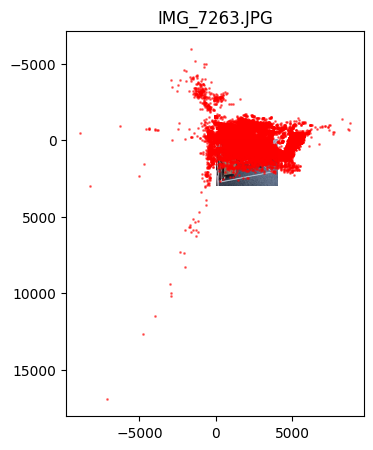

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

print(list(cameras.keys())[:5])   # confirm naming before picking img_name

img_name = list(cameras.keys())[0]
cam = cameras[img_name]
img = Image.open(f"{DATA_ROOT}/images/{img_name}")

P = cam["R"] @ points.T + cam["t"][:, None]
valid = P[2] > 0
x = cam["fx"] * P[0, valid] / P[2, valid] + cam["cx"]
y = cam["fy"] * P[1, valid] / P[2, valid] + cam["cy"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img)
ax.scatter(x, y, s=1, c="red", alpha=0.5)
ax.set_title(img_name)
plt.show()

In [11]:
img_name0 = list(cameras.keys())[0]
recon_cam0 = recon.cameras[recon.images[[i for i in recon.images if recon.images[i].name == img_name0][0]].camera_id]
print(recon_cam0.model.name if hasattr(recon_cam0.model, "name") else recon_cam0.model)
print(recon_cam0.params)

SIMPLE_RADIAL
[3.00564316e+03 2.01600000e+03 1.51200000e+03 3.01946476e-02]


In [12]:
import pycolmap
import numpy as np

recon = pycolmap.Reconstruction(f"{DATA_ROOT}/sparse/0")

cameras = {}
for image_id, image in recon.images.items():
    cam = recon.cameras[image.camera_id]

    pose = image.cam_from_world() if callable(image.cam_from_world) else image.cam_from_world
    R = pose.rotation.matrix()
    t = pose.translation

    K = cam.calibration_matrix()
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]

    cameras[image.name] = {
        "R": R, "t": t,
        "fx": fx, "fy": fy, "cx": cx, "cy": cy,
        "width": cam.width, "height": cam.height,
        "model": cam.model.name if hasattr(cam.model, "name") else str(cam.model),
    }

points = np.array([p.xyz for p in recon.points3D.values()])
colors = np.array([p.color for p in recon.points3D.values()]) / 255.0

print(f"{len(cameras)} cameras, {len(points)} sparse points loaded")
print("camera model:", cameras[list(cameras.keys())[0]]["model"])

122 cameras, 46789 sparse points loaded
camera model: SIMPLE_RADIAL


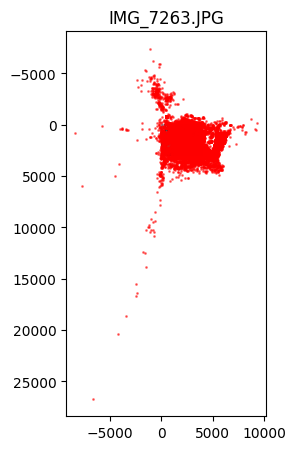

In [13]:
img_name = list(cameras.keys())[0]
cam = cameras[img_name]
img = Image.open(f"{DATA_ROOT}/images/{img_name}")

P = cam["R"] @ points.T + cam["t"][:, None]
valid = P[2] > 0
x = cam["fx"] * P[0, valid] / P[2, valid] + cam["cx"]
y = cam["fy"] * P[1, valid] / P[2, valid] + cam["cy"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img)
ax.scatter(x, y, s=1, c="red", alpha=0.5)
ax.set_title(img_name)
plt.show()

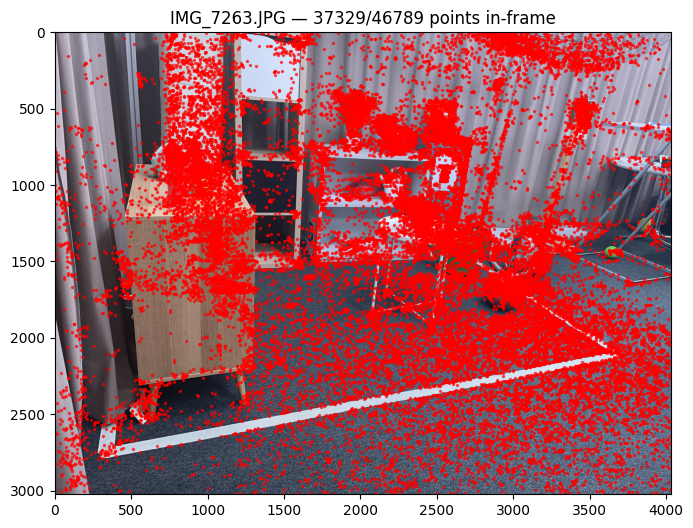

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)

in_bounds = (x >= 0) & (x <= cam["width"]) & (y >= 0) & (y <= cam["height"])
ax.scatter(x[in_bounds], y[in_bounds], s=2, c="red", alpha=0.6)

ax.set_xlim(0, cam["width"])
ax.set_ylim(cam["height"], 0)   # inverted y to match image coords
ax.set_title(f"{img_name} — {in_bounds.sum()}/{len(x)} points in-frame")
plt.show()

In [15]:
import torch
from PIL import Image

device = "cuda"
DOWNSCALE = 4   # 4032x3024 -> 1008x756; raise to 2 later for a higher-quality final pass

image_names = list(cameras.keys())

viewmats_list, Ks_list, gt_images = [], [], []
for name in image_names:
    cam = cameras[name]
    Rt = np.eye(4, dtype=np.float32)
    Rt[:3, :3] = cam["R"]
    Rt[:3, 3] = cam["t"]
    viewmats_list.append(Rt)

    img = Image.open(f"{DATA_ROOT}/images/{name}").convert("RGB")
    new_w, new_h = cam["width"] // DOWNSCALE, cam["height"] // DOWNSCALE
    img = img.resize((new_w, new_h), Image.LANCZOS)
    gt_images.append(torch.from_numpy(np.array(img, dtype=np.float32) / 255.0))

    K = np.array([
        [cam["fx"] / DOWNSCALE, 0, cam["cx"] / DOWNSCALE],
        [0, cam["fy"] / DOWNSCALE, cam["cy"] / DOWNSCALE],
        [0, 0, 1],
    ], dtype=np.float32)
    Ks_list.append(K)

viewmats = torch.tensor(np.stack(viewmats_list), device=device)
Ks = torch.tensor(np.stack(Ks_list), device=device)
gt_images = torch.stack(gt_images).to(device)   # [N, H, W, 3]
img_h, img_w = gt_images.shape[1], gt_images.shape[2]

print(f"{len(image_names)} views loaded at {img_w}x{img_h}")

122 views loaded at 1008x756


In [17]:
import gsplat
from scipy.spatial import cKDTree

tree = cKDTree(points)
dists, _ = tree.query(points, k=4)   # nearest 3 neighbors + self
mean_nn_dist = dists[:, 1:].mean(axis=1)
init_scale = np.clip(mean_nn_dist, 1e-3, None)

N = points.shape[0]
means = torch.tensor(points, dtype=torch.float32, device=device)
scales = torch.tensor(np.log(np.stack([init_scale]*3, axis=1)), dtype=torch.float32, device=device)
quats = torch.zeros(N, 4, device=device); quats[:, 0] = 1.0   # identity rotation
opacities = torch.logit(torch.full((N,), 0.1, device=device))
rgb_colors = torch.tensor(colors, dtype=torch.float32, device=device)

params = {
    "means": torch.nn.Parameter(means),
    "scales": torch.nn.Parameter(scales),
    "quats": torch.nn.Parameter(quats),
    "opacities": torch.nn.Parameter(opacities),
    "colors": torch.nn.Parameter(rgb_colors),
}
print(f"Initialized {N} Gaussians")

Initialized 46789 Gaussians


In [18]:
optimizers = {
    "means":     torch.optim.Adam([params["means"]],     lr=1.6e-4),
    "scales":    torch.optim.Adam([params["scales"]],    lr=5e-3),
    "quats":     torch.optim.Adam([params["quats"]],     lr=1e-3),
    "opacities": torch.optim.Adam([params["opacities"]], lr=5e-2),
    "colors":    torch.optim.Adam([params["colors"]],    lr=2.5e-3),
}

In [19]:
import torch.nn.functional as F
import gsplat

def render_view(idx):
    quats_n = params["quats"] / params["quats"].norm(dim=-1, keepdim=True).clamp_min(1e-8)
    renders, alphas, info = gsplat.rasterization(
        means=params["means"],
        quats=quats_n,
        scales=torch.exp(params["scales"]),
        opacities=torch.sigmoid(params["opacities"]),
        colors=params["colors"].clamp(0, 1),
        viewmats=viewmats[idx:idx+1],
        Ks=Ks[idx:idx+1],
        width=img_w,
        height=img_h,
        sh_degree=None,
    )
    return renders[0, ..., :3], alphas[0, ..., 0]

for it in range(200):
    idx = np.random.randint(0, len(image_names))
    rendered, _ = render_view(idx)
    loss = F.l1_loss(rendered, gt_images[idx])

    for opt in optimizers.values():
        opt.zero_grad()
    loss.backward()
    for opt in optimizers.values():
        opt.step()
    params["colors"].data.clamp_(0, 1)

    if it % 50 == 0:
        print(f"iter {it}: loss {loss.item():.4f}")

Output()

gsplat: CUDA extension has been set up successfully in 300.95 seconds.

iter 0: loss 0.1766
iter 50: loss 0.1118
iter 100: loss 0.1285
iter 150: loss 0.1167


In [20]:
import os
F = __import__("torch.nn.functional", fromlist=["l1_loss"])

CKPT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

N_ITERS = 7000
DENSIFY_FROM, DENSIFY_UNTIL, DENSIFY_EVERY = 500, 5000, 100
GRAD_THRESH = 2e-4
OPACITY_PRUNE_THRESH = 0.005
SCALE_PRUNE_MULT = 20
SPLIT_SCALE_MULT = 1.6

median_init_scale = float(np.median(init_scale))

def render_view(idx, want_grad_info=False):
    quats_n = params["quats"] / params["quats"].norm(dim=-1, keepdim=True).clamp_min(1e-8)
    renders, alphas, info = gsplat.rasterization(
        means=params["means"], quats=quats_n,
        scales=torch.exp(params["scales"]),
        opacities=torch.sigmoid(params["opacities"]),
        colors=params["colors"].clamp(0, 1),
        viewmats=viewmats[idx:idx+1], Ks=Ks[idx:idx+1],
        width=img_w, height=img_h, sh_degree=None, packed=False,
    )
    if want_grad_info:
        info["means2d"].retain_grad()
    return renders[0, ..., :3], alphas[0, ..., 0], info

def rebuild_optimizers():
    global optimizers
    lrs = {"means": 1.6e-4, "scales": 5e-3, "quats": 1e-3, "opacities": 5e-2, "colors": 2.5e-3}
    optimizers = {k: torch.optim.Adam([params[k]], lr=lrs[k]) for k in params}

n_gauss = params["means"].shape[0]
grad_accum = torch.zeros(n_gauss, device=device)
grad_count = torch.zeros(n_gauss, device=device)

for it in range(N_ITERS):
    idx = np.random.randint(0, len(image_names))
    rendered, alpha, info = render_view(idx, want_grad_info=True)
    loss = torch.nn.functional.l1_loss(rendered, gt_images[idx])

    for opt in optimizers.values():
        opt.zero_grad()
    loss.backward()

    if info["means2d"].grad is not None:
        radii0 = info["radii"][0]
        visible = (radii0.sum(-1) > 0) if radii0.dim() > 1 else (radii0 > 0)
        g = info["means2d"].grad[0].norm(dim=-1)
        grad_accum[visible] += g[visible]
        grad_count[visible] += 1

    for opt in optimizers.values():
        opt.step()
    params["colors"].data.clamp_(0, 1)

    if it % 200 == 0 or it == N_ITERS - 1:
        print(f"iter {it:5d}  loss {loss.item():.4f}  n_gaussians {params['means'].shape[0]}")

    if DENSIFY_FROM <= it < DENSIFY_UNTIL and it % DENSIFY_EVERY == 0 and it > 0:
        with torch.no_grad():
            avg_grad = torch.zeros_like(grad_accum)
            has_grad = grad_count > 0
            avg_grad[has_grad] = grad_accum[has_grad] / grad_count[has_grad]

            cur_scales = torch.exp(params["scales"]).mean(dim=-1)
            densify_mask = (avg_grad > GRAD_THRESH) & has_grad
            split_mask = densify_mask & (cur_scales > 2 * median_init_scale)
            clone_mask = densify_mask & ~split_mask

            new_means, new_scales, new_quats, new_opac, new_colors = [], [], [], [], []

            if clone_mask.any():
                new_means.append(params["means"][clone_mask].clone())
                new_scales.append(params["scales"][clone_mask].clone())
                new_quats.append(params["quats"][clone_mask].clone())
                new_opac.append(params["opacities"][clone_mask].clone())
                new_colors.append(params["colors"][clone_mask].clone())

            if split_mask.any():
                k = split_mask.sum().item()
                jitter = torch.randn(k, 3, device=device) * cur_scales[split_mask].unsqueeze(-1)
                new_means.append(params["means"][split_mask] + jitter)
                new_scales.append(params["scales"][split_mask] - np.log(SPLIT_SCALE_MULT))
                new_quats.append(params["quats"][split_mask].clone())
                new_opac.append(params["opacities"][split_mask].clone())
                new_colors.append(params["colors"][split_mask].clone())
                params["scales"].data[split_mask] -= np.log(SPLIT_SCALE_MULT)

            prune_mask = (torch.sigmoid(params["opacities"]) < OPACITY_PRUNE_THRESH) | \
                         (cur_scales > SCALE_PRUNE_MULT * median_init_scale)
            keep_mask = ~prune_mask

            def cat_keep(name, extras):
                base = params[name].data[keep_mask]
                return torch.cat([base] + extras, dim=0) if extras else base

            for name, extras in zip(
                ["means", "scales", "quats", "opacities", "colors"],
                [new_means, new_scales, new_quats, new_opac, new_colors],
            ):
                params[name] = torch.nn.Parameter(cat_keep(name, extras))

            rebuild_optimizers()
            n_gauss = params["means"].shape[0]
            grad_accum = torch.zeros(n_gauss, device=device)
            grad_count = torch.zeros(n_gauss, device=device)

        print(f"  -> densify/prune @ iter {it}: {n_gauss} gaussians remain")

torch.save({k: v.detach().cpu() for k, v in params.items()}, f"{CKPT_DIR}/gaussians_final.pt")
print("Saved checkpoint to", f"{CKPT_DIR}/gaussians_final.pt")

iter     0  loss 0.0808  n_gaussians 46789
iter   200  loss 0.0594  n_gaussians 46789
iter   400  loss 0.0787  n_gaussians 46789
  -> densify/prune @ iter 500: 45792 gaussians remain
iter   600  loss 0.0834  n_gaussians 45792
  -> densify/prune @ iter 600: 45190 gaussians remain
  -> densify/prune @ iter 700: 44708 gaussians remain
iter   800  loss 0.0776  n_gaussians 44708
  -> densify/prune @ iter 800: 44326 gaussians remain
  -> densify/prune @ iter 900: 44001 gaussians remain
iter  1000  loss 0.0692  n_gaussians 44001
  -> densify/prune @ iter 1000: 43689 gaussians remain
  -> densify/prune @ iter 1100: 43436 gaussians remain
iter  1200  loss 0.0548  n_gaussians 43436
  -> densify/prune @ iter 1200: 43246 gaussians remain
  -> densify/prune @ iter 1300: 43014 gaussians remain
iter  1400  loss 0.1119  n_gaussians 43014
  -> densify/prune @ iter 1400: 42831 gaussians remain
  -> densify/prune @ iter 1500: 42674 gaussians remain
iter  1600  loss 0.1512  n_gaussians 42674
  -> densify/

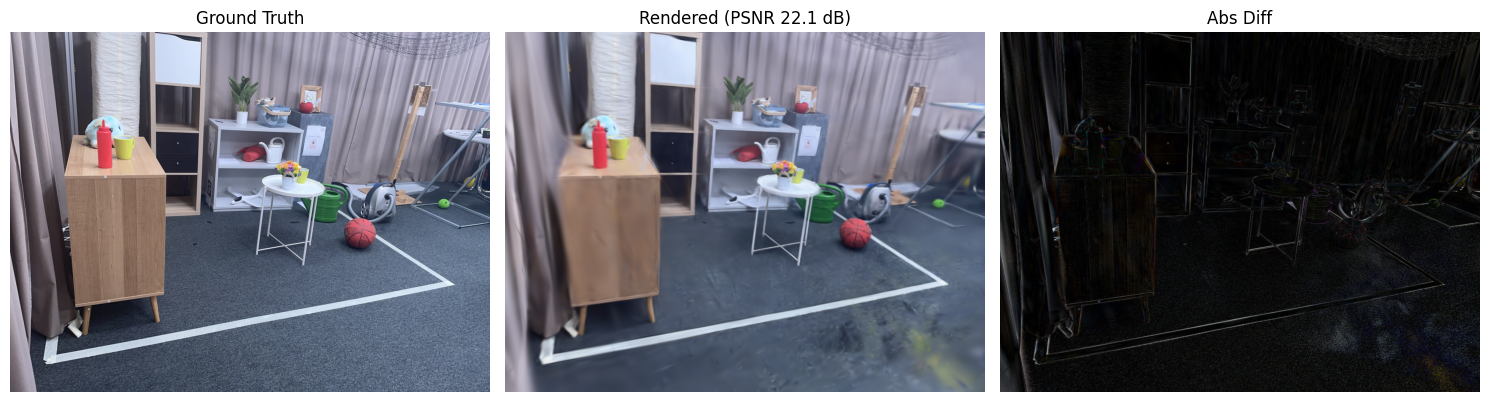

In [21]:
import matplotlib.pyplot as plt

with torch.no_grad():
    test_idx = 0
    rendered, alpha, _ = render_view(test_idx)
    rendered_np = rendered.clamp(0, 1).cpu().numpy()
    gt_np = gt_images[test_idx].cpu().numpy()

mse = np.mean((rendered_np - gt_np) ** 2)
psnr = -10 * np.log10(mse)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_np); axes[0].set_title("Ground Truth")
axes[1].imshow(rendered_np); axes[1].set_title(f"Rendered (PSNR {psnr:.1f} dB)")
axes[2].imshow(np.abs(rendered_np - gt_np)); axes[2].set_title("Abs Diff")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

122 mask files, sample names: ['IMG_7106.JPG', 'IMG_7107.JPG', 'IMG_7108.JPG', 'IMG_7109.JPG', 'IMG_7110.JPG']
mode: L size: (4032, 3024)
unique values: [0 1 2 3 4 5 6 7 8 9] ...


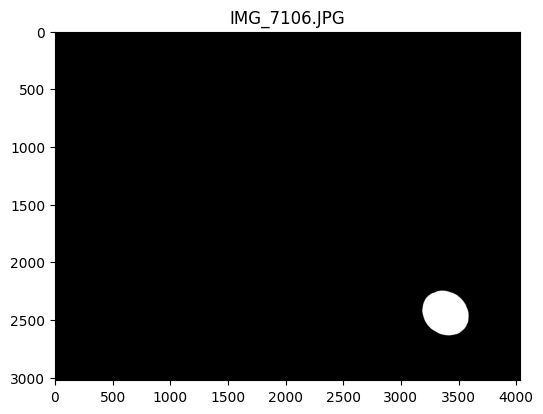

In [22]:
mask_dir = f"{DATA_ROOT}/masks-ball"
mask_files = sorted(os.listdir(mask_dir))
print(f"{len(mask_files)} mask files, sample names: {mask_files[:5]}")

sample_mask = Image.open(f"{mask_dir}/{mask_files[0]}")
print("mode:", sample_mask.mode, "size:", sample_mask.size)
mask_arr = np.array(sample_mask)
print("unique values:", np.unique(mask_arr)[:10], "..." if len(np.unique(mask_arr)) > 10 else "")

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(mask_arr, cmap="gray")
ax.set_title(mask_files[0])
plt.show()

In [23]:
import torch.nn.functional as F

def load_masks(obj_name, target_w, target_h):
    mask_dir = f"{DATA_ROOT}/{obj_name}"
    masks = []
    informative = []
    for name in image_names:
        m = Image.open(f"{mask_dir}/{name}").convert("L").resize((target_w, target_h), Image.NEAREST)
        m_arr = (np.array(m) > 127).astype(np.float32)
        masks.append(m_arr)
        informative.append(m_arr.sum() > 0)
    masks_t = torch.tensor(np.stack(masks), device=device).unsqueeze(1)  # [C,1,H,W]
    informative_t = torch.tensor(informative, device=device)
    return masks_t, informative_t

def compute_consistency_scores(masks_t, informative_t, min_views=3):
    with torch.no_grad():
        means_h = torch.cat([params["means"], torch.ones(params["means"].shape[0], 1, device=device)], dim=1)
        Pcam = torch.einsum('cij,nj->cni', viewmats, means_h)  # [C,N,4]
        z = Pcam[..., 2]
        x_pix = Ks[:, 0, 0:1] * Pcam[..., 0] / z.clamp_min(1e-6) + Ks[:, 0, 2:3]
        y_pix = Ks[:, 1, 1:2] * Pcam[..., 1] / z.clamp_min(1e-6) + Ks[:, 1, 2:3]

        in_bounds = (x_pix >= 0) & (x_pix < img_w) & (y_pix >= 0) & (y_pix < img_h) & (z > 0)
        valid = in_bounds & informative_t.unsqueeze(1)  # [C,N]

        x_norm = (x_pix / (img_w - 1)) * 2 - 1
        y_norm = (y_pix / (img_h - 1)) * 2 - 1
        grid = torch.stack([x_norm, y_norm], dim=-1).unsqueeze(2)  # [C,N,1,2]

        sampled = F.grid_sample(masks_t, grid, mode='nearest', align_corners=True)  # [C,1,N,1]
        hits = sampled[:, 0, :, 0]  # [C,N]

        hit_count = (hits * valid).sum(dim=0)
        view_count = valid.sum(dim=0)

        scores = torch.zeros_like(hit_count)
        enough = view_count >= min_views
        scores[enough] = hit_count[enough] / view_count[enough]

    return scores, view_count

masks_ball, informative_ball = load_masks("masks-ball", img_w, img_h)
print(f"informative views for ball: {informative_ball.sum().item()} / {len(image_names)}")

scores_ball, views_ball = compute_consistency_scores(masks_ball, informative_ball)
print("score distribution:", torch.histc(scores_ball[views_ball >= 3], bins=10, min=0, max=1))

informative views for ball: 113 / 122
score distribution: tensor([38991.,   357.,   180.,   107.,    60.,    60.,    70.,   316.,   353.,
            0.], device='cuda:0')


Selected 799 / 40498 Gaussians at threshold 0.5


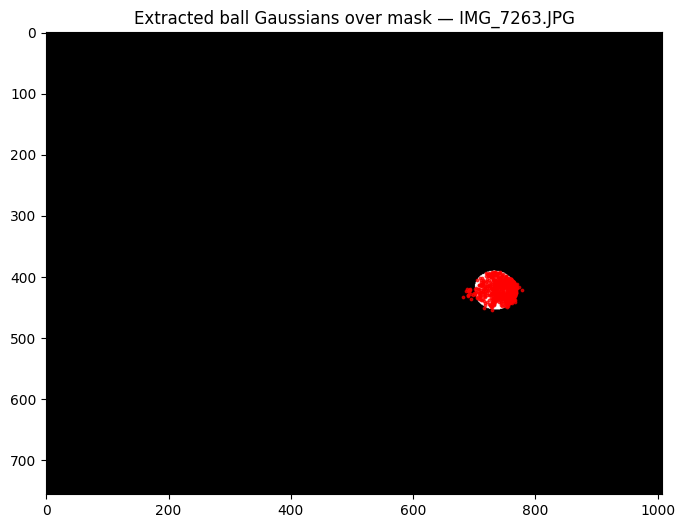

In [24]:
THRESHOLD = 0.5

def extract_object(scores, threshold):
    keep = (scores >= threshold)
    print(f"Selected {keep.sum().item()} / {len(scores)} Gaussians at threshold {threshold}")
    return keep

keep_ball = extract_object(scores_ball, THRESHOLD)

# Visual check: project kept Gaussian centers onto a view where the ball is visible, overlay on its mask
check_idx = next(i for i, n in enumerate(image_names) if informative_ball[i])
cam_R, cam_t = viewmats[check_idx, :3, :3], viewmats[check_idx, :3, 3]
K = Ks[check_idx]

with torch.no_grad():
    pts = params["means"][keep_ball]
    Pcam = (cam_R @ pts.T).T + cam_t
    z = Pcam[:, 2]
    x_pix = (K[0, 0] * Pcam[:, 0] / z.clamp_min(1e-6) + K[0, 2]).cpu().numpy()
    y_pix = (K[1, 1] * Pcam[:, 1] / z.clamp_min(1e-6) + K[1, 2]).cpu().numpy()

mask_img = masks_ball[check_idx, 0].cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(mask_img, cmap="gray")
ax.scatter(x_pix, y_pix, s=3, c="red", alpha=0.7)
ax.set_title(f"Extracted ball Gaussians over mask — {image_names[check_idx]}")
plt.show()

In [25]:
def extract_and_check(obj_name, threshold=0.5, min_views=3):
    masks_t, informative_t = load_masks(obj_name, img_w, img_h)
    print(f"[{obj_name}] informative views: {informative_t.sum().item()} / {len(image_names)}")

    scores, views = compute_consistency_scores(masks_t, informative_t, min_views=min_views)
    valid_scores = scores[views >= min_views]
    print(f"[{obj_name}] score histogram:", torch.histc(valid_scores, bins=10, min=0, max=1).cpu().numpy())

    keep = scores >= threshold
    print(f"[{obj_name}] selected {keep.sum().item()} / {len(scores)} Gaussians")
    return keep, masks_t, informative_t

keep_cupboard1, masks_c1, informative_c1 = extract_and_check("masks-cupboard")
keep_cupboard2, masks_c2, informative_c2 = extract_and_check("masks-cupboard-2")

[masks-cupboard] informative views: 116 / 122
[masks-cupboard] score histogram: [37970.   553.   350.   238.   134.   115.   144.   289.   616.    76.]
[masks-cupboard] selected 1240 / 40498 Gaussians
[masks-cupboard-2] informative views: 116 / 122
[masks-cupboard-2] score histogram: [36828.  2066.   377.   214.   101.   209.   152.   181.   363.     0.]
[masks-cupboard-2] selected 905 / 40498 Gaussians


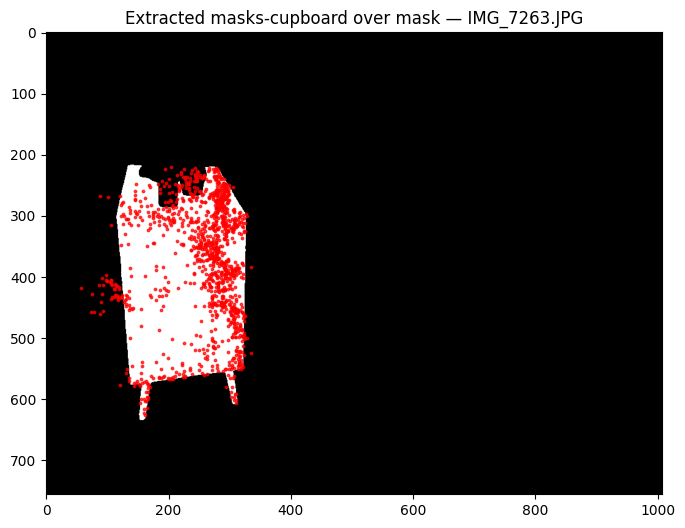

In [26]:
def visual_check(obj_name, keep_mask, masks_t, informative_t, scores):
    check_idx = next(i for i in range(len(image_names)) if informative_t[i])
    cam_R, cam_t = viewmats[check_idx, :3, :3], viewmats[check_idx, :3, 3]
    K = Ks[check_idx]

    with torch.no_grad():
        pts = params["means"][keep_mask]
        Pcam = (cam_R @ pts.T).T + cam_t
        z = Pcam[:, 2]
        x_pix = (K[0, 0] * Pcam[:, 0] / z.clamp_min(1e-6) + K[0, 2]).cpu().numpy()
        y_pix = (K[1, 1] * Pcam[:, 1] / z.clamp_min(1e-6) + K[1, 2]).cpu().numpy()

    mask_img = masks_t[check_idx, 0].cpu().numpy()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(mask_img, cmap="gray")
    ax.scatter(x_pix, y_pix, s=3, c="red", alpha=0.7)
    ax.set_title(f"Extracted {obj_name} over mask — {image_names[check_idx]}")
    plt.show()

scores_c1, _ = compute_consistency_scores(masks_c1, informative_c1)
visual_check("masks-cupboard", keep_cupboard1, masks_c1, informative_c1, scores_c1)

In [27]:
from scipy.spatial import cKDTree

def spatial_filter(keep_mask, eps=None, min_cluster_frac=0.05):
    """Keep only Gaussians belonging to the largest connected spatial cluster."""
    idxs = torch.nonzero(keep_mask).squeeze(-1).cpu().numpy()
    if len(idxs) < 10:
        return keep_mask

    pts = params["means"][keep_mask].detach().cpu().numpy()
    if eps is None:
        tree = cKDTree(pts)
        d, _ = tree.query(pts, k=2)
        eps = np.median(d[:, 1]) * 8  # adaptive radius based on local point spacing

    tree = cKDTree(pts)
    pairs = tree.query_pairs(r=eps, output_type="ndarray")

    # union-find for connected components
    parent = np.arange(len(pts))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[ra] = rb

    for a, b in pairs:
        union(a, b)

    roots = np.array([find(i) for i in range(len(pts))])
    labels, counts = np.unique(roots, return_counts=True)
    largest = labels[np.argmax(counts)]
    cluster_mask_local = (roots == largest)

    print(f"  spatial filter: {cluster_mask_local.sum()}/{len(pts)} kept "
          f"({len(labels)} clusters found, eps={eps:.4f})")

    new_keep = torch.zeros_like(keep_mask)
    new_keep[idxs[cluster_mask_local]] = True
    return new_keep

keep_ball_clean = spatial_filter(keep_ball)
keep_cupboard1_clean = spatial_filter(keep_cupboard1)
keep_cupboard2_clean = spatial_filter(keep_cupboard2)

  spatial filter: 766/799 kept (3 clusters found, eps=0.1750)
  spatial filter: 1183/1240 kept (6 clusters found, eps=0.3619)
  spatial filter: 898/905 kept (5 clusters found, eps=0.4371)


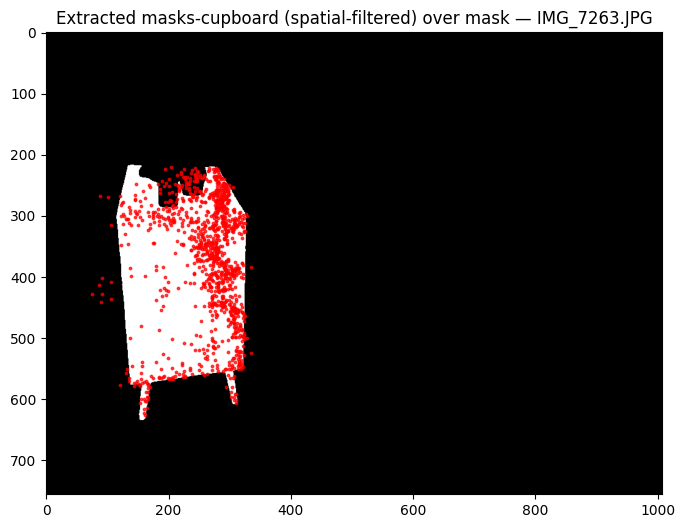

In [28]:
visual_check("masks-cupboard (spatial-filtered)", keep_cupboard1_clean, masks_c1, informative_c1, scores_c1)

  DBSCAN (eps=0.1357, min_samples=6): 490/1240 kept, 16 clusters, 110 noise points


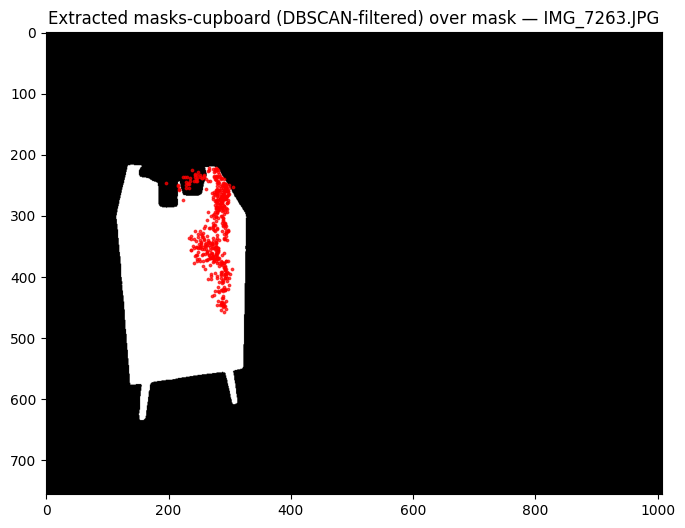

In [29]:
from sklearn.cluster import DBSCAN

def spatial_filter_v2(keep_mask, eps_mult=3.0, min_samples=6):
    idxs = torch.nonzero(keep_mask).squeeze(-1).cpu().numpy()
    if len(idxs) < min_samples:
        return keep_mask

    pts = params["means"][keep_mask].detach().cpu().numpy()
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=2)
    eps = np.median(d[:, 1]) * eps_mult

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(pts)
    valid_labels = labels[labels >= 0]
    if len(valid_labels) == 0:
        print("  no clusters found, returning original mask")
        return keep_mask

    vals, counts = np.unique(valid_labels, return_counts=True)
    largest = vals[np.argmax(counts)]
    cluster_mask_local = (labels == largest)

    print(f"  DBSCAN (eps={eps:.4f}, min_samples={min_samples}): "
          f"{cluster_mask_local.sum()}/{len(pts)} kept, "
          f"{len(vals)} clusters, {np.sum(labels == -1)} noise points")

    new_keep = torch.zeros_like(keep_mask)
    new_keep[idxs[cluster_mask_local]] = True
    return new_keep

keep_cupboard1_v2 = spatial_filter_v2(keep_cupboard1)
visual_check("masks-cupboard (DBSCAN-filtered)", keep_cupboard1_v2, masks_c1, informative_c1, scores_c1)

  DBSCAN (eps=0.0905): 37 clusters found, sizes [np.int64(105), np.int64(99), np.int64(81), np.int64(63), np.int64(53), np.int64(52), np.int64(48), np.int64(39)]..., kept 17 clusters totaling 765/1240 points, 344 pure noise points dropped


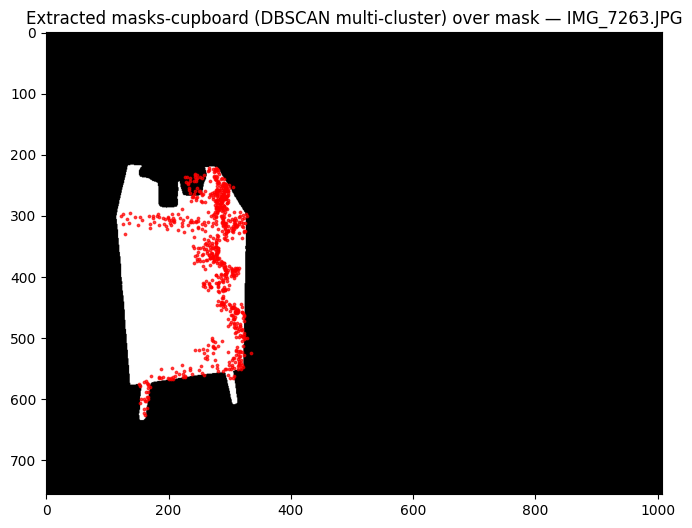

In [30]:
def spatial_filter_v3(keep_mask, eps_mult=2.0, min_samples=5, size_frac_thresh=0.02):
    idxs = torch.nonzero(keep_mask).squeeze(-1).cpu().numpy()
    if len(idxs) < min_samples:
        return keep_mask

    pts = params["means"][keep_mask].detach().cpu().numpy()
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=2)
    eps = np.median(d[:, 1]) * eps_mult

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(pts)
    valid_labels = labels[labels >= 0]
    if len(valid_labels) == 0:
        print("  no clusters found, returning original mask")
        return keep_mask

    vals, counts = np.unique(valid_labels, return_counts=True)
    total = counts.sum()
    keep_clusters = vals[counts >= size_frac_thresh * total]

    cluster_mask_local = np.isin(labels, keep_clusters)

    print(f"  DBSCAN (eps={eps:.4f}): {len(vals)} clusters found, sizes {sorted(counts, reverse=True)[:8]}..., "
          f"kept {len(keep_clusters)} clusters totaling {cluster_mask_local.sum()}/{len(pts)} points, "
          f"{np.sum(labels == -1)} pure noise points dropped")

    new_keep = torch.zeros_like(keep_mask)
    new_keep[idxs[cluster_mask_local]] = True
    return new_keep

keep_cupboard1_v3 = spatial_filter_v3(keep_cupboard1)
visual_check("masks-cupboard (DBSCAN multi-cluster)", keep_cupboard1_v3, masks_c1, informative_c1, scores_c1)

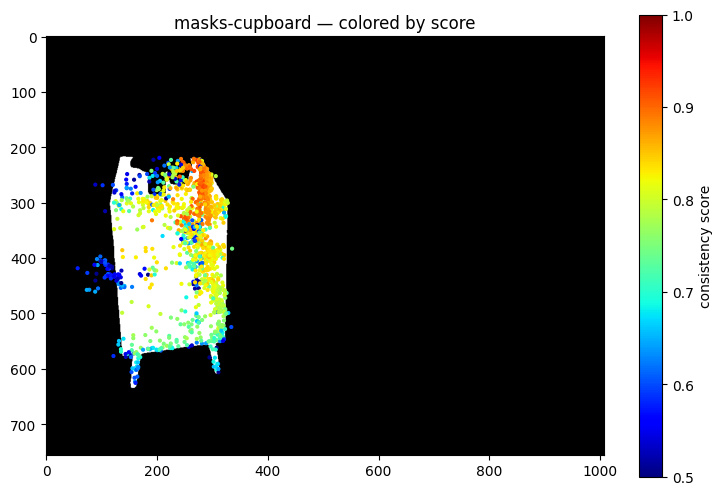

In [31]:
def visual_check_scored(obj_name, keep_mask, masks_t, informative_t, scores):
    check_idx = next(i for i in range(len(image_names)) if informative_t[i])
    cam_R, cam_t = viewmats[check_idx, :3, :3], viewmats[check_idx, :3, 3]
    K = Ks[check_idx]

    with torch.no_grad():
        pts = params["means"][keep_mask]
        pt_scores = scores[keep_mask].cpu().numpy()
        Pcam = (cam_R @ pts.T).T + cam_t
        z = Pcam[:, 2]
        x_pix = (K[0, 0] * Pcam[:, 0] / z.clamp_min(1e-6) + K[0, 2]).cpu().numpy()
        y_pix = (K[1, 1] * Pcam[:, 1] / z.clamp_min(1e-6) + K[1, 2]).cpu().numpy()

    mask_img = masks_t[check_idx, 0].cpu().numpy()
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.imshow(mask_img, cmap="gray")
    sc = ax.scatter(x_pix, y_pix, s=4, c=pt_scores, cmap="jet", vmin=0.5, vmax=1.0)
    plt.colorbar(sc, label="consistency score")
    ax.set_title(f"{obj_name} — colored by score")
    plt.show()

visual_check_scored("masks-cupboard", keep_cupboard1, masks_c1, informative_c1, scores_c1)

At threshold 0.8: 692 / 40498 Gaussians


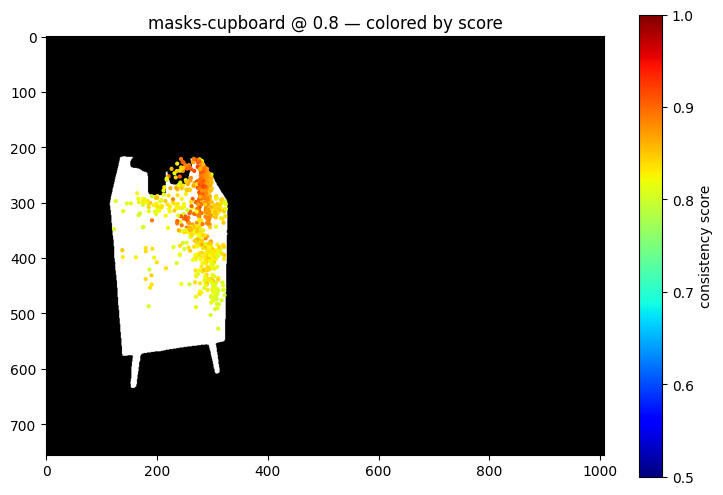

In [32]:
THRESHOLD_TEST = 0.8
keep_test = scores_c1 >= THRESHOLD_TEST
print(f"At threshold {THRESHOLD_TEST}: {keep_test.sum().item()} / {len(scores_c1)} Gaussians")
visual_check_scored("masks-cupboard @ 0.8", keep_test, masks_c1, informative_c1, scores_c1)

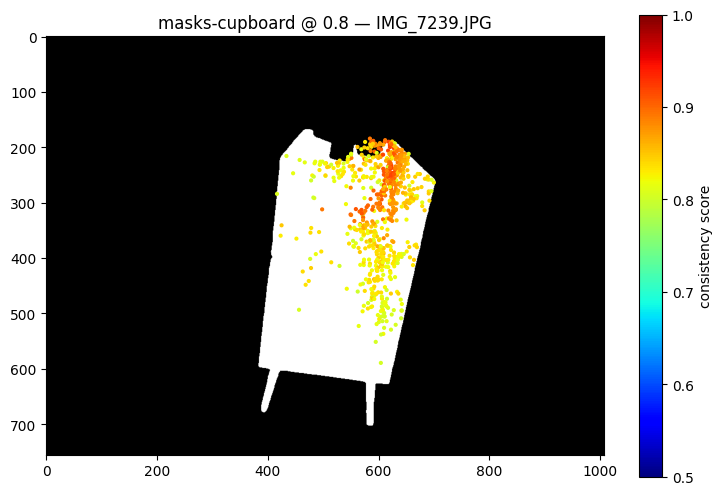

In [33]:
check_idx2 = [i for i, n in enumerate(image_names) if informative_c1[i]][20]  # a different informative view
def visual_check_scored_idx(obj_name, keep_mask, masks_t, scores, idx):
    cam_R, cam_t = viewmats[idx, :3, :3], viewmats[idx, :3, 3]
    K = Ks[idx]
    with torch.no_grad():
        pts = params["means"][keep_mask]
        pt_scores = scores[keep_mask].cpu().numpy()
        Pcam = (cam_R @ pts.T).T + cam_t
        z = Pcam[:, 2]
        x_pix = (K[0, 0] * Pcam[:, 0] / z.clamp_min(1e-6) + K[0, 2]).cpu().numpy()
        y_pix = (K[1, 1] * Pcam[:, 1] / z.clamp_min(1e-6) + K[1, 2]).cpu().numpy()
    mask_img = masks_t[idx, 0].cpu().numpy()
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.imshow(mask_img, cmap="gray")
    sc = ax.scatter(x_pix, y_pix, s=4, c=pt_scores, cmap="jet", vmin=0.5, vmax=1.0)
    plt.colorbar(sc, label="consistency score")
    ax.set_title(f"{obj_name} — {image_names[idx]}")
    plt.show()

keep_08 = scores_c1 >= 0.8
visual_check_scored_idx("masks-cupboard @ 0.8", keep_08, masks_c1, scores_c1, check_idx2)

In [34]:
from plyfile import PlyData, PlyElement

FINAL_THRESHOLD = 0.8

scores_ball_final, _ = compute_consistency_scores(masks_ball, informative_ball)
scores_c2_final, _ = compute_consistency_scores(masks_c2, informative_c2)

keep_ball_final = scores_ball_final >= FINAL_THRESHOLD
keep_c1_final = scores_c1 >= FINAL_THRESHOLD
keep_c2_final = scores_c2_final >= FINAL_THRESHOLD

print(f"ball:       {keep_ball_final.sum().item()} / {len(scores_ball_final)}")
print(f"cupboard:   {keep_c1_final.sum().item()} / {len(scores_c1)}")
print(f"cupboard-2: {keep_c2_final.sum().item()} / {len(scores_c2_final)}")

OUT_DIR = "/kaggle/working/extracted_objects"
os.makedirs(OUT_DIR, exist_ok=True)

def save_object_ply(keep_mask, filename):
    with torch.no_grad():
        means = params["means"][keep_mask].cpu().numpy()
        scales = torch.exp(params["scales"][keep_mask]).cpu().numpy()
        quats = (params["quats"][keep_mask] / params["quats"][keep_mask].norm(dim=-1, keepdim=True)).cpu().numpy()
        opacities = torch.sigmoid(params["opacities"][keep_mask]).cpu().numpy()
        colors = params["colors"][keep_mask].clamp(0, 1).cpu().numpy()

    n = means.shape[0]
    dtype = [("x", "f4"), ("y", "f4"), ("z", "f4"),
             ("scale_0", "f4"), ("scale_1", "f4"), ("scale_2", "f4"),
             ("rot_0", "f4"), ("rot_1", "f4"), ("rot_2", "f4"), ("rot_3", "f4"),
             ("opacity", "f4"),
             ("red", "f4"), ("green", "f4"), ("blue", "f4")]
    data = np.zeros(n, dtype=dtype)
    data["x"], data["y"], data["z"] = means[:, 0], means[:, 1], means[:, 2]
    data["scale_0"], data["scale_1"], data["scale_2"] = scales[:, 0], scales[:, 1], scales[:, 2]
    data["rot_0"], data["rot_1"], data["rot_2"], data["rot_3"] = quats[:, 0], quats[:, 1], quats[:, 2], quats[:, 3]
    data["opacity"] = opacities
    data["red"], data["green"], data["blue"] = colors[:, 0], colors[:, 1], colors[:, 2]

    el = PlyElement.describe(data, "vertex")
    path = f"{OUT_DIR}/{filename}"
    PlyData([el]).write(path)
    print(f"saved {n} gaussians -> {path}")

save_object_ply(keep_ball_final, "object-ball.ply")
save_object_ply(keep_c1_final, "object-cupboard-1.ply")
save_object_ply(keep_c2_final, "object-cupboard-2.ply")

ball:       353 / 40498
cupboard:   692 / 40498
cupboard-2: 363 / 40498
saved 353 gaussians -> /kaggle/working/extracted_objects/object-ball.ply
saved 692 gaussians -> /kaggle/working/extracted_objects/object-cupboard-1.ply
saved 363 gaussians -> /kaggle/working/extracted_objects/object-cupboard-2.ply


In [35]:
# Camera centers in world space: C = -R^T @ t  (since x_cam = R x_world + t)
cam_centers = []
cam_ups = []
for i in range(len(image_names)):
    R = viewmats[i, :3, :3].cpu().numpy()
    t = viewmats[i, :3, 3].cpu().numpy()
    C = -R.T @ t
    cam_centers.append(C)
    cam_ups.append(R.T @ np.array([0, -1, 0]))  # COLMAP/OpenCV: camera "up" is -y in cam frame

cam_centers = np.array(cam_centers)
scene_up = np.mean(cam_ups, axis=0)
scene_up /= np.linalg.norm(scene_up)

with torch.no_grad():
    obj_pts = torch.cat([
        params["means"][keep_ball_final],
        params["means"][keep_c1_final],
        params["means"][keep_c2_final],
    ], dim=0).cpu().numpy()
scene_center = obj_pts.mean(axis=0)

print("scene_up:", scene_up)
print("scene_center (objects centroid):", scene_center)
print("camera center radius range:", np.linalg.norm(cam_centers - scene_center, axis=1).min(),
      "to", np.linalg.norm(cam_centers - scene_center, axis=1).max())

scene_up: [-0.15678683 -0.98317975 -0.09367745]
scene_center (objects centroid): [-3.2979379   0.07415132  6.278601  ]
camera center radius range: 4.8993297 to 11.318856


novel camera positions: (60, 3)


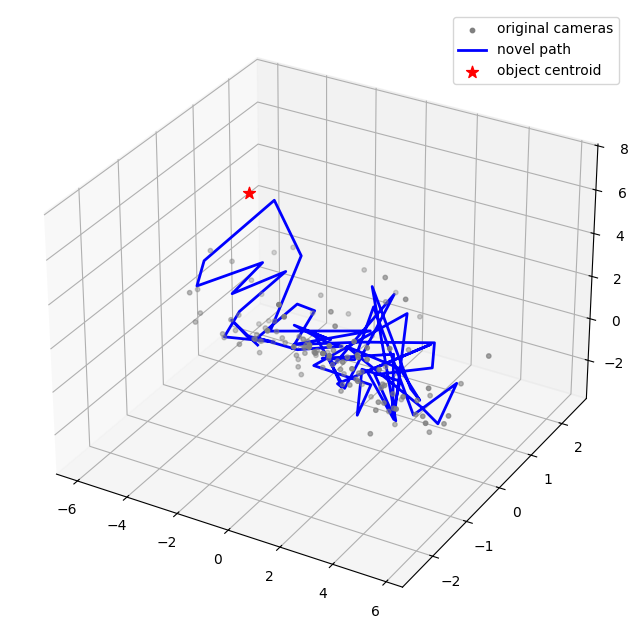

In [36]:
from scipy.interpolate import splprep, splev

def build_basis(up):
    arbitrary = np.array([1.0, 0, 0]) if abs(up[0]) < 0.9 else np.array([0, 1.0, 0])
    right = np.cross(up, arbitrary); right /= np.linalg.norm(right)
    fwd = np.cross(right, up); fwd /= np.linalg.norm(fwd)
    return right, fwd

basis_right, basis_fwd = build_basis(scene_up)

rel = cam_centers - scene_center
angles = np.arctan2(rel @ basis_fwd, rel @ basis_right)
order = np.argsort(angles)
ordered_centers = cam_centers[order]

pts = np.vstack([ordered_centers, ordered_centers[0]])  # close the loop
tck, _ = splprep([pts[:, 0], pts[:, 1], pts[:, 2]], s=len(pts) * 0.01, per=1)

N_NOVEL_VIEWS = 60
u_new = np.linspace(0, 1, N_NOVEL_VIEWS, endpoint=False)
novel_positions = np.array(splev(u_new, tck)).T

print("novel camera positions:", novel_positions.shape)

# 3D visualization to sanity-check the path before building view matrices
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(cam_centers[:, 0], cam_centers[:, 1], cam_centers[:, 2], c="gray", s=10, label="original cameras")
ax.plot(novel_positions[:, 0], novel_positions[:, 1], novel_positions[:, 2], c="blue", lw=2, label="novel path")
ax.scatter(*scene_center, c="red", s=80, marker="*", label="object centroid")
ax.legend()
plt.show()

median step distance: 1.9893847
max step distance: 8.686301
first-to-last distance: 3.8651738


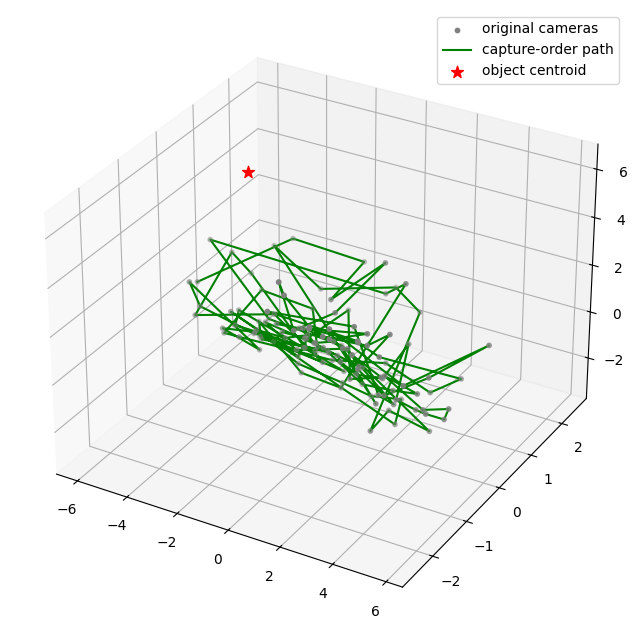

In [37]:
# Order by filename sequence (capture order) instead of re-derived angle
filename_order = np.argsort(image_names)  # IMG_#### sorts correctly as strings here since same digit count
ordered_centers_seq = cam_centers[filename_order]

# Check: is consecutive-frame distance much smaller than the overall spread?
step_dists = np.linalg.norm(np.diff(ordered_centers_seq, axis=0), axis=1)
print("median step distance:", np.median(step_dists))
print("max step distance:", np.max(step_dists))
print("first-to-last distance:", np.linalg.norm(ordered_centers_seq[0] - ordered_centers_seq[-1]))

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(cam_centers[:, 0], cam_centers[:, 1], cam_centers[:, 2], c="gray", s=10, label="original cameras")
ax.plot(ordered_centers_seq[:, 0], ordered_centers_seq[:, 1], ordered_centers_seq[:, 2], c="green", lw=1.5, label="capture-order path")
ax.scatter(*scene_center, c="red", s=80, marker="*", label="object centroid")
ax.legend()
plt.show()

In [38]:
def robust_median(keep_mask):
    return np.median(params["means"][keep_mask].detach().cpu().numpy(), axis=0)

scene_center = np.mean([robust_median(keep_ball_final), robust_median(keep_c1_final), robust_median(keep_c2_final)], axis=0)

rel = cam_centers - scene_center
dist = np.linalg.norm(rel, axis=1)
orbit_radius = np.median(dist)
orbit_elev = np.median(np.arcsin(np.clip((rel @ scene_up) / dist, -1, 1)))

def build_basis(up):
    arbitrary = np.array([1.0, 0, 0]) if abs(up[0]) < 0.9 else np.array([0, 1.0, 0])
    right = np.cross(up, arbitrary); right /= np.linalg.norm(right)
    fwd = np.cross(right, up); fwd /= np.linalg.norm(fwd)
    return right, fwd

basis_right, basis_fwd = build_basis(scene_up)

def lookat_w2c(pos, target, up):
    forward = target - pos; forward /= np.linalg.norm(forward)
    right = np.cross(forward, up); right /= np.linalg.norm(right)
    down = np.cross(forward, right)
    Rc2w = np.stack([right, down, forward], axis=1)
    Rw2c = Rc2w.T
    return Rw2c, -Rw2c @ pos

N_NOVEL = 36
novel_viewmats = []
for a in np.linspace(0, 2 * np.pi, N_NOVEL, endpoint=False):
    horiz = np.cos(a) * basis_right + np.sin(a) * basis_fwd
    pos = scene_center + orbit_radius * np.cos(orbit_elev) * horiz + orbit_radius * np.sin(orbit_elev) * scene_up
    Rw2c, tw2c = lookat_w2c(pos, scene_center, scene_up)
    M = np.eye(4, dtype=np.float32); M[:3, :3] = Rw2c; M[:3, 3] = tw2c
    novel_viewmats.append(M)

novel_viewmats = torch.tensor(np.stack(novel_viewmats), device=device)
novel_K = Ks.mean(dim=0, keepdim=True).repeat(N_NOVEL, 1, 1)
print(f"generated {N_NOVEL} novel cameras, radius={orbit_radius:.2f}, elevation={np.degrees(orbit_elev):.1f}°")

generated 36 novel cameras, radius=7.53, elevation=1.8°


ball: 36 views rendered
cupboard-1: 36 views rendered
cupboard-2: 36 views rendered


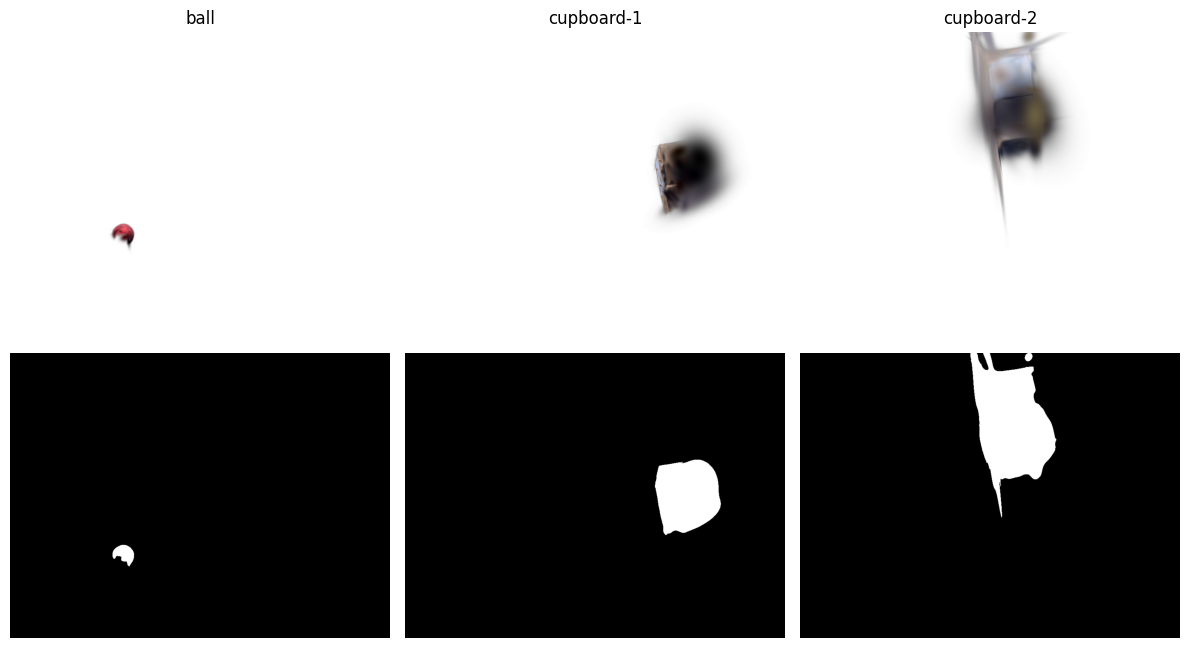

zipped -> /kaggle/working/deliverable.zip


In [39]:
def render_subset(keep_mask, viewmat, K, width, height, bg=(1.0, 1.0, 1.0)):
    with torch.no_grad():
        q = params["quats"][keep_mask]
        q = q / q.norm(dim=-1, keepdim=True).clamp_min(1e-8)
        renders, alphas, _ = gsplat.rasterization(
            means=params["means"][keep_mask], quats=q,
            scales=torch.exp(params["scales"][keep_mask]),
            opacities=torch.sigmoid(params["opacities"][keep_mask]),
            colors=params["colors"][keep_mask].clamp(0, 1),
            viewmats=viewmat.unsqueeze(0), Ks=K.unsqueeze(0),
            width=width, height=height, sh_degree=None,
        )
    rgb = renders[0, ..., :3].cpu().numpy()
    alpha = alphas[0, ..., 0].cpu().numpy()
    bg_arr = np.array(bg)
    composited = (rgb * alpha[..., None] + bg_arr * (1 - alpha[..., None])) * 255
    mask = (alpha > 0.5).astype(np.uint8) * 255
    return composited.clip(0, 255).astype(np.uint8), mask

objects = {"ball": keep_ball_final, "cupboard-1": keep_c1_final, "cupboard-2": keep_c2_final}
OUT_ROOT = "/kaggle/working/output"
for name in objects:
    os.makedirs(f"{OUT_ROOT}/rgb/{name}", exist_ok=True)
    os.makedirs(f"{OUT_ROOT}/masks/{name}", exist_ok=True)

for name, keep_mask in objects.items():
    for vi in range(N_NOVEL):
        rgb_img, mask_img = render_subset(keep_mask, novel_viewmats[vi], novel_K[vi], img_w, img_h)
        Image.fromarray(rgb_img).save(f"{OUT_ROOT}/rgb/{name}/view_{vi:03d}.png")
        Image.fromarray(mask_img).save(f"{OUT_ROOT}/masks/{name}/view_{vi:03d}.png")
    print(f"{name}: {N_NOVEL} views rendered")

# one combined quick-look so you can eyeball quality before zipping
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for col, name in enumerate(objects):
    axes[0, col].imshow(Image.open(f"{OUT_ROOT}/rgb/{name}/view_000.png")); axes[0, col].set_title(name); axes[0, col].axis("off")
    axes[1, col].imshow(Image.open(f"{OUT_ROOT}/masks/{name}/view_000.png"), cmap="gray"); axes[1, col].axis("off")
plt.tight_layout(); plt.show()

import shutil
shutil.make_archive("/kaggle/working/deliverable", "zip", OUT_ROOT)
print("zipped -> /kaggle/working/deliverable.zip")